# 03 — Imbalanced Data Analysis & SMOTE
**Loan Approval Prediction**

Goals:
- Quantify class imbalance
- Show the impact of imbalance on a naive baseline
- Apply SMOTE (Synthetic Minority Over-sampling Technique)
- Compare class distributions before and after oversampling
- Try RandomUnderSampler as an alternative
- Save balanced datasets for use in modelling notebooks

**Prerequisite**: Notebook 02 must have been run.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from src.config import DATA_DIR, TARGET_COL, RANDOM_STATE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score

print("Data directory:", DATA_DIR)

Data directory: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/data


## 1. Load Preprocessed Data

In [2]:
import numpy as np

X_train = np.load(os.path.join(DATA_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")

X_train : (3415, 11)   y_train : (3415,)
X_test  : (854, 11)    y_test  : (854,)


## 2. Class Distribution Analysis

Training set class distribution:
  Class 0 (Rejected):  1290  (37.8%)
  Class 1 (Approved):  2125  (62.2%)

Imbalance ratio (majority/minority): 1.65


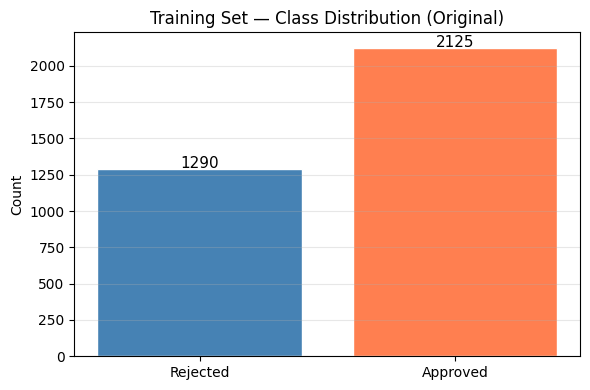

In [3]:
unique, counts = np.unique(y_train, return_counts=True)

print("Training set class distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)} ({'Approved' if label == 1 else 'Rejected'}): {count:>5}  ({count/len(y_train)*100:.1f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}")

# Bar chart of training class distribution
labels_text = ['Approved' if u == 1 else 'Rejected' for u in unique]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels_text, counts, color=['steelblue', 'coral'], edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 5, str(h), ha='center', fontsize=11)
ax.set_title('Training Set — Class Distribution (Original)', fontsize=12)
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Naive Baseline — Impact of Imbalance

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Naive Baseline (always predict majority class):")
print(classification_report(y_test, y_pred_dummy, target_names=['Rejected', 'Approved']))
print(f"Macro F1: {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")
print("\nThis demonstrates why accuracy alone is misleading for imbalanced data.")
print("A model that always predicts 'Approved' can achieve high accuracy but has 0 recall for Rejected.")

Naive Baseline (always predict majority class):
              precision    recall  f1-score   support

    Rejected       0.00      0.00      0.00       323
    Approved       0.62      1.00      0.77       531

    accuracy                           0.62       854
   macro avg       0.31      0.50      0.38       854
weighted avg       0.39      0.62      0.48       854

Macro F1: 0.3834

This demonstrates why accuracy alone is misleading for imbalanced data.
A model that always predicts 'Approved' can achieve high accuracy but has 0 recall for Rejected.


/mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_4_Loan_Approval_Prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 

## 4. Apply SMOTE (Over-sampling)

In [5]:
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

unique_s, counts_s = np.unique(y_smote, return_counts=True)
print("After SMOTE:")
for label, count in zip(unique_s, counts_s):
    print(f"  Class {int(label)} ({'Approved' if label == 1 else 'Rejected'}): {count:>5}")

print(f"\nAdded {len(X_smote) - len(X_train)} synthetic samples.")

After SMOTE:
  Class 0 (Rejected):  2125
  Class 1 (Approved):  2125

Added 835 synthetic samples.


## 5. Apply RandomUnderSampler (Under-sampling)

In [6]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = rus.fit_resample(X_train, y_train)

unique_u, counts_u = np.unique(y_under, return_counts=True)
print("After RandomUnderSampler:")
for label, count in zip(unique_u, counts_u):
    print(f"  Class {int(label)} ({'Approved' if label == 1 else 'Rejected'}): {count:>5}")

print(f"\nRemoved {len(X_train) - len(X_under)} majority class samples.")

After RandomUnderSampler:
  Class 0 (Rejected):  1290
  Class 1 (Approved):  1290

Removed 835 majority class samples.


## 6. Visual Comparison

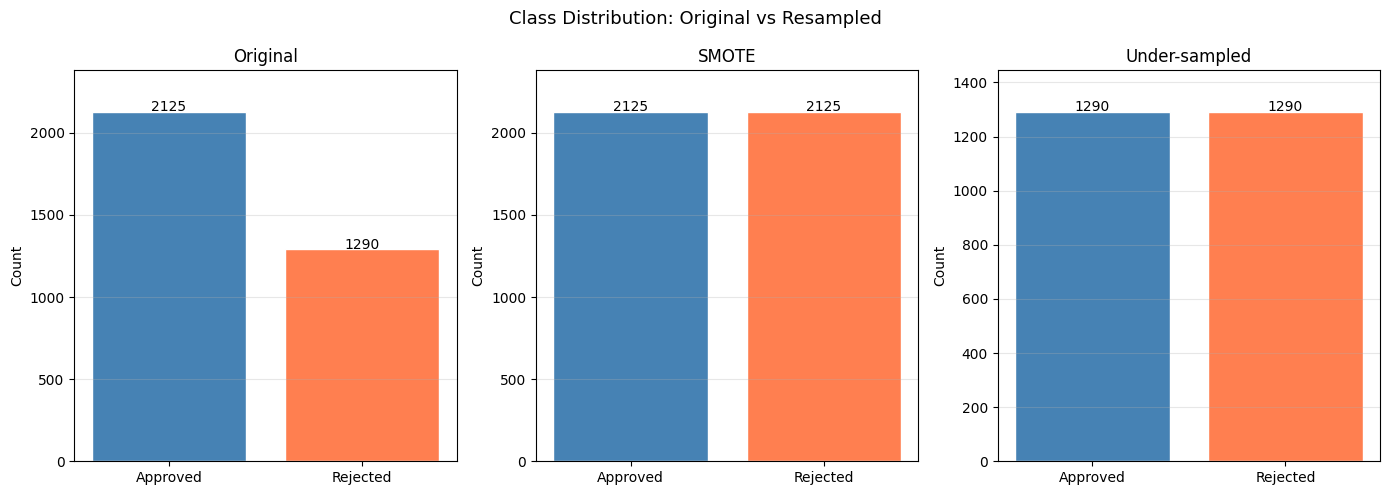

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

datasets = [
    ('Original',      y_train),
    ('SMOTE',         y_smote),
    ('Under-sampled', y_under),
]

for ax, (name, y_data) in zip(axes, datasets):
    approved_count  = int((y_data == 1).sum())
    rejected_count  = int((y_data == 0).sum())
    vals = [approved_count, rejected_count]
    bars = ax.bar(['Approved', 'Rejected'], vals,
                  color=['steelblue', 'coral'], edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 5,
                str(h), ha='center', fontsize=10)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(vals) * 1.12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution: Original vs Resampled', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Save Balanced Datasets

In [8]:
np.save(os.path.join(DATA_DIR, 'X_smote.npy'), X_smote)
np.save(os.path.join(DATA_DIR, 'y_smote.npy'), y_smote)
np.save(os.path.join(DATA_DIR, 'X_under.npy'), X_under)
np.save(os.path.join(DATA_DIR, 'y_under.npy'), y_under)

print("Saved:")
print(f"  data/X_smote.npy  ({X_smote.shape})")
print(f"  data/y_smote.npy  ({y_smote.shape})")
print(f"  data/X_under.npy  ({X_under.shape})")
print(f"  data/y_under.npy  ({y_under.shape})")

Saved:
  data/X_smote.npy  ((4250, 11))
  data/y_smote.npy  ((4250,))
  data/X_under.npy  ((2580, 11))
  data/y_under.npy  ((2580,))


## 8. Summary

| Dataset | Approved | Rejected | Total |
|---------|----------|----------|-------|
| Original train | majority | minority | n |
| SMOTE | balanced | balanced | larger |
| Under-sampled | balanced | balanced | smaller |

**Recommendation**: SMOTE is preferred as it preserves information. Under-sampling discards real data.

Both balanced sets are saved to `data/` and will be used in notebooks 04 and 05 for comparison.